In [11]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [6]:
class Result(TypedDict):

  maths: float
  physics:float
  marks: float
  verdict: str
  

In [12]:

def cal_marks(state: Result):
  marks = (state['maths'] + state['physics'])/2
  return {'marks' : marks}
  
def result_pass(state: Result):
  print("congratulations!! you got passes")
  return state

def result_fail(state: Result):
  print("better luck next time")
  return state

def decide(state: Result)->Literal["result pass", "result fail"]:
  if state['marks'] >= 33:
    return "result pass"
  else:
    return "result fail"

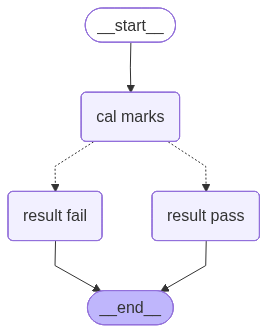

In [13]:
graph = StateGraph(Result)
graph.add_node("cal marks",cal_marks)
graph.add_node("result pass",result_pass)
graph.add_node("result fail",result_fail)

graph.add_edge(START,"cal marks")
graph.add_conditional_edges("cal marks",decide)
graph.add_edge("result pass",END)
graph.add_edge("result fail",END)

workflow = graph.compile()

workflow



In [17]:
initial_state = {'physics' : 25,'maths':40}
final_state = workflow.invoke(initial_state)

better luck next time
